In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Import given data “milk.csv”

In [9]:
ds = pd.read_csv('data/milk.csv')

ds.shape

(169, 2)

## 2. display first 5 rows and last five rows of the data

In [10]:
ds.head()

,Month,Monthly milk production: pounds per cow. Jan 62 ? Dec 75
0,1962-01,589.0
1,1962-02,561.0
2,1962-03,640.0
3,1962-04,656.0
4,1962-05,727.0


In [11]:
ds.tail()

,Month,Monthly milk production: pounds per cow. Jan 62 ? Dec 75
164,1975-09,817.0
165,1975-10,827.0
166,1975-11,797.0
167,1975-12,843.0
168,Monthly milk production: pounds per cow. Jan 6...,NaN


In [12]:
ds = ds.drop(ds.index[-1])
ds.columns = ['Month', 'Monthly Milk Production: pounds per cow']

ds.tail(3)

,Month,Monthly Milk Production: pounds per cow
165,1975-10,827.0
166,1975-11,797.0
167,1975-12,843.0


## 3. Convert the data type of month column from object data type to datetime format.

In [13]:
ds['Month'] = pd.to_datetime(ds['Month'], format='%Y-%m')

ds['Month'].head()

0   1962-01-01
1   1962-02-01
2   1962-03-01
3   1962-04-01
4   1962-05-01
Name: Month, dtype: datetime64[us]

## 4. set month column as the index of the dataframe.

In [14]:
ds = ds.set_index('Month')
ds.index = pd.DatetimeIndex(ds.index, freq='MS')

ds.head()

,Monthly Milk Production: pounds per cow
Month,
1962-01-01,589.0
1962-02-01,561.0
1962-03-01,640.0
1962-04-01,656.0
1962-05-01,727.0


## 5. Show the line-plot of the given time series data

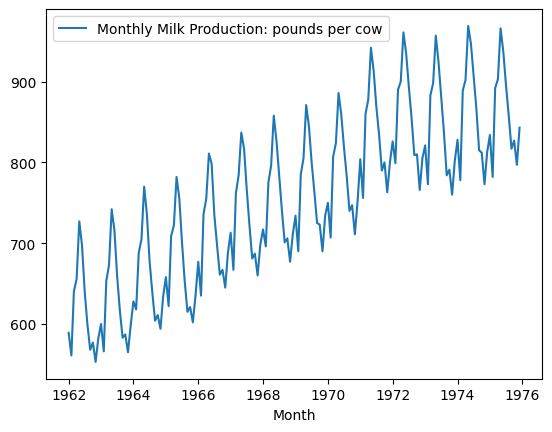

In [15]:
sns.lineplot(data=ds)
plt.show()

## 6 Import seasonal_decompose from the statsmodels package

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

## 7. Pass data frame into the seasonal_decompose method and plot the result

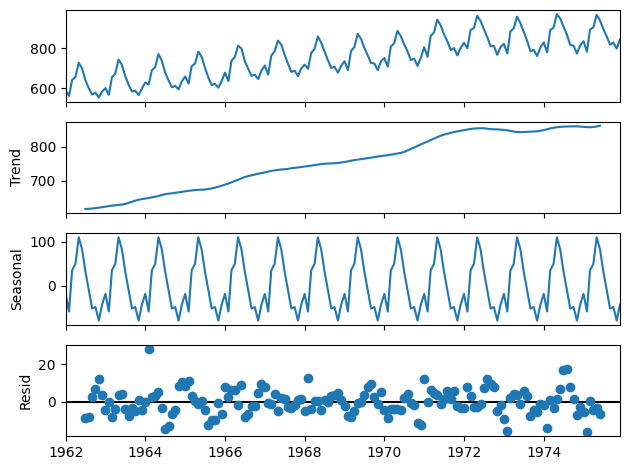

In [17]:
decomposition = seasonal_decompose(ds)
decomposition.plot()
plt.show()

## 8. Import the augmented Dickey-Fuller test from the statsmodels package

In [18]:
from statsmodels.tsa.stattools import adfuller

## 9. Comment on the stationarity of data

In [19]:
result = adfuller(ds)

print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print("Critical Values:")
for key, value in result[4].items():
    print(f'   {key}: {value}')

ADF Statistic: -1.3038
p-value: 0.6274
Critical Values:
   1%: -3.473542528196209
   5%: -2.880497674144038
   10%: -2.576878053634677


## 10. Divide the data in training and testing set. Plot the data with different colors

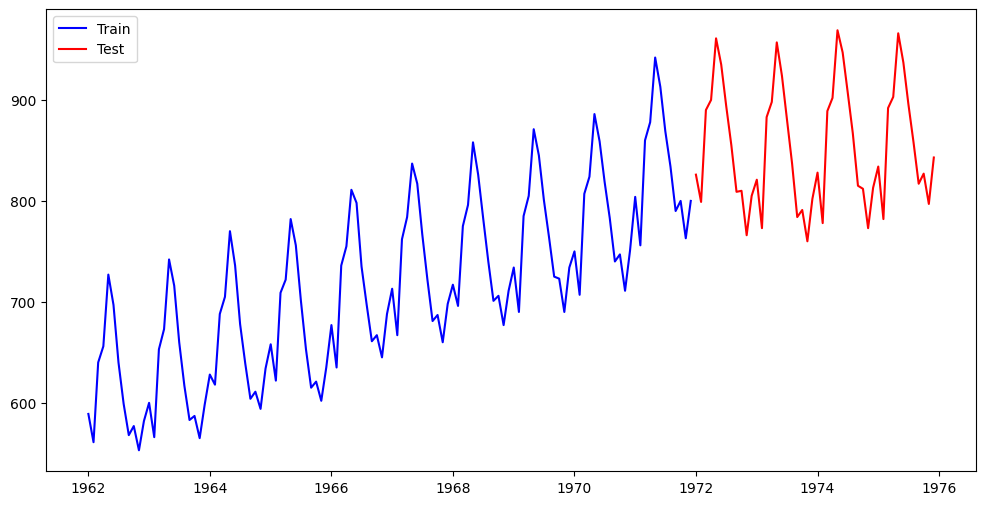

In [20]:
# 70-30 ratio of train-test splitting
train = ds[:120]
test = ds[120:]

plt.figure(figsize=(12,6))
plt.plot(train, color='blue', label='Train')
plt.plot(test, color='red', label='Test')
plt.legend()
plt.show()

## 11. Apply ARIMA model of order(1,1,2) and generate predictions 

In [21]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(1,1,2))
model_fit = model.fit()

predictions = model_fit.forecast(steps=len(test))
predictions.index = test.index

## 12. Display train data, test data and predicted data with different colored lines

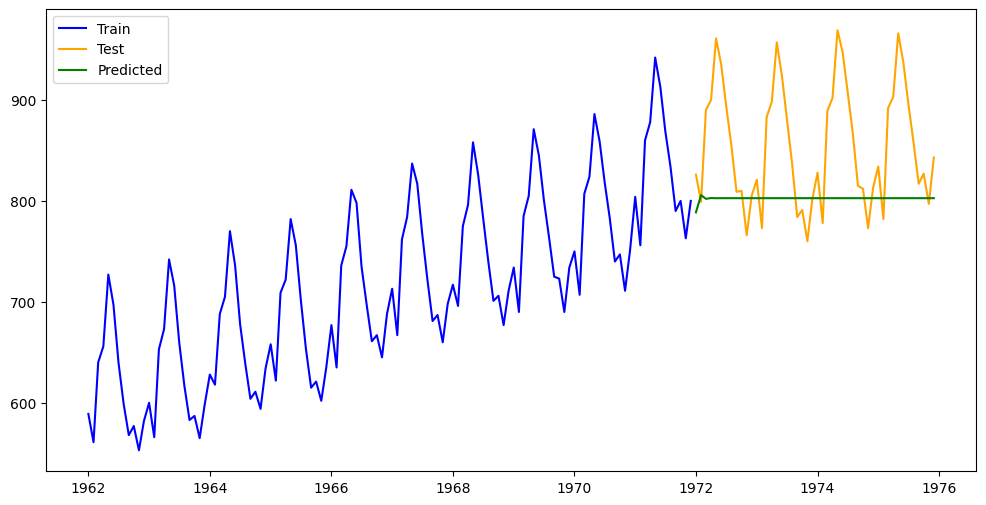

In [22]:
plt.figure(figsize=(12,6))
plt.plot(train, color='blue', label='Train')
plt.plot(test, color='orange', label='Test')
plt.plot(predictions, color='green', label='Predicted')
plt.legend()
plt.show()

## 13. Calculate root mean squared error (RMSE) between test data and predicted data

In [23]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(test, predictions))
print('RMSE:', rmse)

RMSE: 79.11222204039117
